In [2]:
import numpy as np
import yfinance as fy
import QuantLib as ql
from typing import Optional, Union
import pandas as pd
import matplotlib.pyplot as plt
import mocaxpy
import multiprocess
import seaborn as sb

from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.utils import timer
from inception.quantlib_python import date_to_date
from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote

In [3]:
def autocallable_note_pricer(x: list, additonal_data = None):
    """
    The Autocallable Notes pricer function wrapper, (adapts the original function signature to the signature expected by MoCaX)
    :param x: [stock A price, stock B price, stock C price, days after the start date]
    :param additional_data: extra parameters required by MoCaX
    """
    import numpy as np
    import pandas as pd
    from inception.instruments.constant_parameters import NOTES_PARAMETERS
    from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote
    
    start_date = '2024-02-14'
    # Input parameters:
    spot_price = np.array(x[:3])
    eval_date = pd.Timestamp(start_date) + pd.Timedelta(days=x[3])
    
    corr_matrix = np.array(
        [[1.        , 0.96432854, 0.80799003],
        [0.96432854, 1.        , 0.8267037 ],
        [0.80799003, 0.8267037 , 1.        ]]
    )
    issued_price = [382.82, 494.08, 142.86]
    index_vol = [0.16, 0.16, 0.16]
    risk_free_rate = 0.05
    path_num = 100_000
    d_s = 0.02
    parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, corr_matrix, d_s)
    notes = MultiAssetAutoCallableNote(eval_date,
                                       ['A', 'B', 'C'],
                                       simulator, 
                                       parameters['valuation dates'],
                                       parameters['coupon dates'],
                                       parameters['call dates'],
                                       coupon_barrier=parameters['coupon barrier'],
                                       call_barrier=parameters['call barrier'],
                                       principal_barrier=parameters['principal barrier'],
                                       coupon_amount=parameters['coupon amount'],
                                       free_rate=risk_free_rate,
                                       n_paths=path_num)

    
    return notes.value

In [4]:
autocallable_note_pricer([382.82, 494.08, 142.86, 0])

101.73046598313306

In [5]:
parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
start_date =  pd.Timestamp('2024-02-14')
days_interval = [(pd.Timestamp(d) - start_date).days for d in parameters['valuation dates']]
days_periods = list(zip([0] + [d + 1 for d in days_interval[:-1]], days_interval))
days_periods

[(0, 90),
 (91, 182),
 (183, 274),
 (275, 366),
 (367, 455),
 (456, 547),
 (548, 639),
 (640, 734),
 (735, 820),
 (821, 912),
 (913, 1006),
 (1007, 1098),
 (1099, 1185),
 (1186, 1279),
 (1280, 1370),
 (1371, 1461)]

In [6]:
def autocallable_notes_chebyshev_approximate(time_bucket: int, pricer):
    """
    Using Chebyshev Tensor to approximate the Autocallable notes pricer
    :param time_bucket: the time period index
    :return:
    """
    from inception.instruments.constant_parameters import NOTES_PARAMETERS
    import pandas as pd
    import mocaxpy
    import numpy as np
    import os
    
    parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
    start_date =  pd.Timestamp('2024-02-14')
    days_interval = [(pd.Timestamp(d) - start_date).days for d in parameters['valuation dates']]
    days_periods = list(zip([0] + [d + 1 for d in days_interval[:-1]], days_interval))

    # Number of dimensions
    num_dimensions_per_partial = [3, 1]

    # Function domain for stock A, B and C price, Time to Maturity
    issued_price = [382.82, 494.08, 142.86]

    lower_bound = 0.2
    upper_bound = 1.5

    domain_values = [
        [issued_price[0] * lower_bound, issued_price[0] * upper_bound] ,  # Stock A price
        [issued_price[1] * lower_bound, issued_price[1] * upper_bound] ,  # Stock B price
        [issued_price[2] * lower_bound, issued_price[2] * upper_bound] ,  # Stock C price
        list(days_periods[time_bucket])                                   # Days after the start date
    ]
    domain = mocaxpy.MocaxDomain(domain_values)

    # MoCaX accuracy parameters, Chebyshev Nodes
    n_nodes = [15, 15, 15, 7]
    mocax_nodes = mocaxpy.MocaxNs(n_nodes)
    
    # Reference point (must be inside the domain of the function)
    reference_point = issued_price + [np.mean(days_periods[time_bucket])]

    option_mocax = mocaxpy.MocaxSliding(pricer, num_dimensions_per_partial, domain, mocax_nodes, reference_point)
    
    file_dir = f'./chebyshev_database/'
    if not os.path.exists(file_dir):
        os.makedirs(file_dir)
        
    file_name = file_dir + f'autocallable_notes_period_{time_bucket+1}_sliding.mcx'
    option_mocax.serialize(file_name)
    

In [26]:
autocallable_notes_chebyshev_approximate(0, autocallable_note_pricer)

In [7]:
option_mocax = mocaxpy.MocaxSliding.deserialize("./chebyshev_database/autocallable_notes_period_1_sliding.mcx")

In [8]:
x = [282.82, 404.08, 192.86, 80]
print(autocallable_note_pricer(x))
import time

t1 = time.time()
for _ in range(1000):
    a = option_mocax.eval(x)
    
print((time.time() - t1)/1000)
print(option_mocax.eval(x))

90.277175579002
5.13458251953125e-05
91.60372472731117


In [11]:
func = lambda x: np.random.uniform(x * 0.2, x * 1.5)
value_m = []
value_p = []
issued_price = [382.82, 494.08, 142.86]

for _ in range(100):
    x = [func(d) for d in issued_price] + [np.random.choice(np.arange(0, 91))]
    value_m.append(option_mocax.eval(x))
    value_p.append(autocallable_note_pricer(x))

4.715212789488606


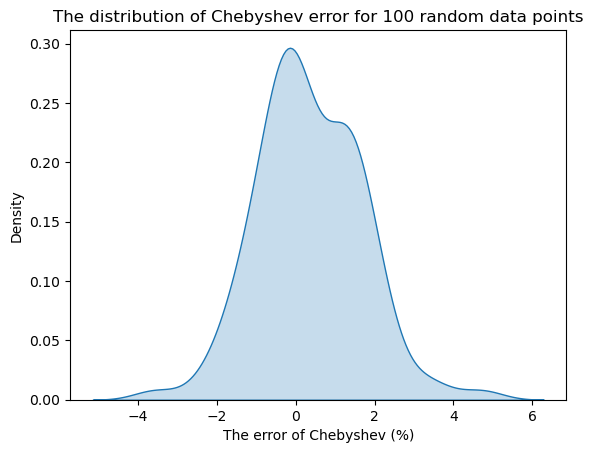

In [12]:
error_2 = (np.array(value_p) - np.array(value_m)) / np.array(value_p) * 100
sb.kdeplot(error_2,fill=True)
plt.title('The distribution of Chebyshev error for 100 random data points')
plt.xlabel('The error of Chebyshev (%)')
print(max(abs(error_2)))

In [ ]:
## Anil

# Please run three times, and remove the comments in different intervals each time
# --------------------------------------------------
time_bucket_1 = (0, autocallable_note_pricer)
time_bucket_2 = (1, autocallable_note_pricer)
time_bucket_3 = (2, autocallable_note_pricer)
time_bucket_4 = (3, autocallable_note_pricer)

# time_bucket_1 = (6, autocallable_note_pricer)
# time_bucket_2 = (7, autocallable_note_pricer)
# time_bucket_3 = (8, autocallable_note_pricer)
# time_bucket_4 = (9, autocallable_note_pricer)

# time_bucket_1 = (10, autocallable_note_pricer)
# time_bucket_2 = (11, autocallable_note_pricer)
# time_bucket_3 = (12, autocallable_note_pricer)
# time_bucket_4 = (13, autocallable_note_pricer)

# time_bucket_1 = (14, autocallable_note_pricer)
# time_bucket_2 = (15, autocallable_note_pricer)

# --------------------------------------------------

p1 = multiprocess.Process(target=autocallable_notes_chebyshev_approximate, args=time_bucket_1)
p2 = multiprocess.Process(target=autocallable_notes_chebyshev_approximate, args=time_bucket_2)
p3 = multiprocess.Process(target=autocallable_notes_chebyshev_approximate, args=time_bucket_3)
p4 = multiprocess.Process(target=autocallable_notes_chebyshev_approximate, args=time_bucket_4)

# starting process 1
p1.start()
# starting process 2
p2.start()
# starting process 3
p3.start()
# starting process 3
p4.start()

# wait until process 1 is finished
p1.join()
# wait until process 2 is finished
p2.join()
p3.join()
p4.join()

# both processes finished
print("Done!")